# Instrumental Variable (IV) Methods — Reusable Analysis Template

This notebook is a **plug-and-play template** implementing the instrumental-variable
methods from *"An Experimental Perspective of the Instrumental Variable"* and the
following chapters (encouragement designs & noncompliance, disentangling mixture
distributions / IV inequalities, the econometric TSLS perspective, fuzzy regression
discontinuity, and Mendelian Randomization).

**How to use this notebook**

1. Run the *Setup* cell.
2. Jump to the section that matches your design (see the table below) and replace the
   synthetic example with your own `Z`, `D`, `Y` (and `X`) arrays / DataFrame columns.
3. Each section is self-contained: it defines reusable functions, then demonstrates
   them on simulated data so you can see the expected output shape before plugging in
   real data.

| Your design | Go to section |
|---|---|
| Encouragement design, binary instrument, individual data | §2 Wald / CACE estimator |
| ... with pre-treatment covariates | §3 Covariate-adjusted (Lin) estimator |
| Instrument might be weak (τ̂D near 0) | §4 Weak-IV robust (Fieller–Anderson–Rubin) CI |
| Binary D & Y — want to test the IV assumptions | §5 Disentangling mixtures / IV inequalities |
| General linear model, continuous/multiple instruments | §6 Two-Stage Least Squares (TSLS) |
| Running variable with a fuzzy jump in treatment probability | §7 Fuzzy Regression Discontinuity |
| Only GWAS-style summary statistics across many instruments | §8 Mendelian Randomization |

> Pair this notebook with the companion **Applicability Checklist & Key Takeaways**
> document to decide which section applies to your project and which assumptions you
> need to defend.


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

rng = np.random.default_rng(2026)
plt.rcParams["figure.figsize"] = (7, 4.5)
pd.set_option("display.precision", 4)


## 1. Simulate (or load) an encouragement-design dataset

Replace `simulate_encouragement_data` with your own data loader
(e.g. `df = pd.read_csv("your_data.csv")`). The rest of the notebook only assumes you
end up with 1-D numpy arrays `Z`, `D`, `Y` (0/1 assignment, 0/1 or continuous
received-treatment, and outcome), and optionally a covariate matrix `X`.


In [2]:
def simulate_encouragement_data(n=2000, pi_c=0.4, pi_a=0.15, tau_c=2.0, seed=1):
    """Simulate an encouragement design with always-takers, compliers, never-takers.
    Returns a DataFrame with columns Z, D, Y, X1, X2, U (U = latent type, for reference only).
    """
    rs = np.random.default_rng(seed)
    pi_n = 1 - pi_c - pi_a
    U = rs.choice(["a", "c", "n"], size=n, p=[pi_a, pi_c, pi_n])
    Z = rs.binomial(1, 0.5, size=n)

    D1 = np.where(np.isin(U, ["a", "c"]), 1, 0)   # D(1)
    D0 = np.where(U == "a", 1, 0)                  # D(0)
    D = np.where(Z == 1, D1, D0)

    X1 = rs.normal(0, 1, size=n)
    X2 = rs.binomial(1, 0.5, size=n)

    # Exclusion restriction: Y(1)=Y(0) for always-takers & never-takers (no direct Z effect)
    base = 5 + 0.5 * X1 + 0.3 * X2
    Y0 = base + rs.normal(0, 1, size=n)
    Y1 = Y0 + tau_c * (U == "c")  # only compliers get an effect of being assigned Z=1
    Y = np.where(Z == 1, Y1, Y0)

    return pd.DataFrame({"Z": Z, "D": D, "Y": Y, "X1": X1, "X2": X2, "U": U})

df = simulate_encouragement_data()
df.head()


,Z,D,Y,X1,X2,U
0,0,0,3.5633,-0.7406,0,c
1,0,0,5.1269,0.1771,1,n
2,0,1,3.9981,-1.3559,0,a
3,0,0,6.3640,-0.2240,1,n
4,0,0,4.9051,1.0903,0,c


## 2. Wald / CACE estimator (Ch. 21)

The Complier Average Causal Effect (CACE, a.k.a. LATE) under randomization,
monotonicity, and exclusion restriction:

$$\hat\tau_c = \frac{\hat\tau_Y}{\hat\tau_D} = \frac{\bar Y_{Z=1} - \bar Y_{Z=0}}{\bar D_{Z=1} - \bar D_{Z=0}}$$

with standard error from the delta method (adjusted-outcome trick) or the bootstrap.


In [3]:
def iv_wald(Z, D, Y):
    """Point estimates: (tau_D, tau_Y, CACE)."""
    Z, D, Y = map(np.asarray, (Z, D, Y))
    tau_D = Y[Z == 1].size and (D[Z == 1].mean() - D[Z == 0].mean())
    tau_Y = Y[Z == 1].mean() - Y[Z == 0].mean()
    cace = tau_Y / tau_D
    return tau_D, tau_Y, cace


def iv_wald_delta(Z, D, Y):
    """CACE and its delta-method SE (Neyman-type variance of the adjusted outcome)."""
    Z, D, Y = map(np.asarray, (Z, D, Y))
    tau_D, tau_Y, cace = iv_wald(Z, D, Y)
    adj_y = Y - D * cace
    var_adj = adj_y[Z == 1].var(ddof=1) / (Z == 1).sum() + adj_y[Z == 0].var(ddof=1) / (Z == 0).sum()
    se = np.sqrt(var_adj) / abs(tau_D)
    return cace, se


def iv_wald_bootstrap(Z, D, Y, n_boot=1000, seed=0):
    """CACE and its bootstrap SE."""
    Z, D, Y = map(np.asarray, (Z, D, Y))
    _, _, cace = iv_wald(Z, D, Y)
    rs = np.random.default_rng(seed)
    n = len(Z)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rs.integers(0, n, n)
        boots[b] = iv_wald(Z[idx], D[idx], Y[idx])[2]
    return cace, boots.std(ddof=1)


tau_D, tau_Y, cace = iv_wald(df.Z, df.D, df.Y)
cace_delta, se_delta = iv_wald_delta(df.Z, df.D, df.Y)
cace_boot, se_boot = iv_wald_bootstrap(df.Z, df.D, df.Y, n_boot=500)

print(f"First stage  (tau_D):  {tau_D:.4f}")
print(f"ITT effect   (tau_Y):  {tau_Y:.4f}")
print(f"CACE / LATE  (Wald):   {cace:.4f}")
print(f"  delta-method SE:     {se_delta:.4f}   95% CI: "
      f"[{cace_delta - 1.96*se_delta:.4f}, {cace_delta + 1.96*se_delta:.4f}]")
print(f"  bootstrap SE:        {se_boot:.4f}   95% CI: "
      f"[{cace_boot - 1.96*se_boot:.4f}, {cace_boot + 1.96*se_boot:.4f}]")


First stage  (tau_D):  0.4040
ITT effect   (tau_Y):  0.8178
CACE / LATE  (Wald):   2.0241
  delta-method SE:     0.1460   95% CI: [1.7379, 2.3102]
  bootstrap SE:        0.1488   95% CI: [1.7325, 2.3157]


## 3. Covariate-adjusted estimator (Lin, 2013) (Ch. 21.3)

Adjusts both the first stage (D) and the reduced form (Y) for pre-treatment covariates
`X` using Lin's interacted OLS estimator, then forms the ratio. Standard errors are
obtained by the bootstrap.


In [4]:
def _lin_coef(Z, Y, X):
    """Lin (2013) estimator: coefficient of Z in OLS of Y on (1, Z, X_centered, Z*X_centered)."""
    Z = np.asarray(Z, dtype=float)
    Y = np.asarray(Y, dtype=float)
    X = np.asarray(X, dtype=float)
    Xc = (X - X.mean(axis=0)) / X.std(axis=0, ddof=1)
    design = np.column_stack([np.ones_like(Z), Z, Xc, Z[:, None] * Xc])
    beta = np.linalg.lstsq(design, Y, rcond=None)[0]
    return beta[1]


def iv_lin(Z, D, Y, X):
    tau_D = _lin_coef(Z, D, X)
    tau_Y = _lin_coef(Z, Y, X)
    return tau_D, tau_Y, tau_Y / tau_D


def iv_lin_bootstrap(Z, D, Y, X, n_boot=500, seed=0):
    Z, D, Y, X = np.asarray(Z), np.asarray(D), np.asarray(Y), np.asarray(X)
    _, _, cace = iv_lin(Z, D, Y, X)
    rs = np.random.default_rng(seed)
    n = len(Z)
    boots = np.empty(n_boot)
    for b in range(n_boot):
        idx = rs.integers(0, n, n)
        boots[b] = iv_lin(Z[idx], D[idx], Y[idx], X[idx])[2]
    return cace, boots.std(ddof=1)


X = df[["X1", "X2"]].values
cace_lin, se_lin = iv_lin_bootstrap(df.Z, df.D, df.Y, X, n_boot=500)
print(f"Covariate-adjusted CACE: {cace_lin:.4f}   bootstrap SE: {se_lin:.4f}   "
      f"95% CI: [{cace_lin - 1.96*se_lin:.4f}, {cace_lin + 1.96*se_lin:.4f}]")


Covariate-adjusted CACE: 2.0026   bootstrap SE: 0.1375   95% CI: [1.7331, 2.2721]


## 4. Weak-IV-robust confidence set: Fieller–Anderson–Rubin (FAR) (Ch. 21.4)

When the first stage is weak (`tau_D` near 0), the Wald-estimator's sampling
distribution is far from Normal and its CI can badly under-cover. The FAR approach
inverts a sequence of tests of `H0(b): tau_c = b` using the adjusted outcome
`A_i(b) = Y_i - b * D_i`, and is robust regardless of instrument strength.


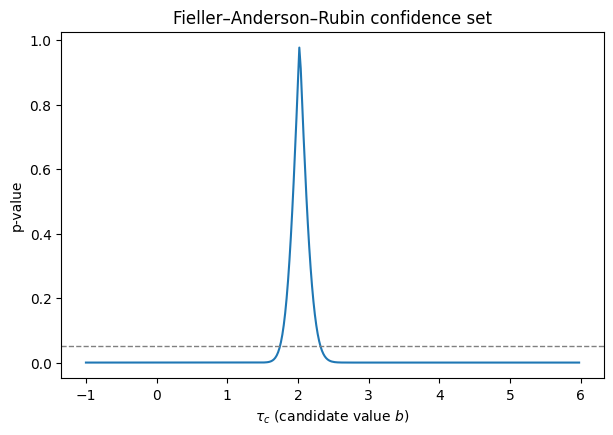

FAR 95% confidence interval: [1.760, 2.320]
(compare to the Wald-type CI from Section 2 above)


In [5]:
def far_confidence_set(Z, D, Y, grid):
    """Return grid values and two-sided p-values for H0(b): tau_c = b."""
    Z, D, Y = np.asarray(Z), np.asarray(D), np.asarray(Y)
    pvals = np.empty_like(grid, dtype=float)
    for i, b in enumerate(grid):
        A = Y - b * D
        tau_adj = A[Z == 1].mean() - A[Z == 0].mean()
        var_adj = A[Z == 1].var(ddof=1) / (Z == 1).sum() + A[Z == 0].var(ddof=1) / (Z == 0).sum()
        t_stat = tau_adj / np.sqrt(var_adj)
        pvals[i] = 2 * (1 - stats.norm.cdf(abs(t_stat)))
    return pvals


grid = np.arange(-1, 6, 0.02)
pvals = far_confidence_set(df.Z, df.D, df.Y, grid)
far_ci = grid[pvals >= 0.05]

plt.plot(grid, pvals)
plt.axhline(0.05, color="grey", linestyle="--", linewidth=1)
plt.xlabel(r"$\tau_c$ (candidate value $b$)")
plt.ylabel("p-value")
plt.title("Fieller–Anderson–Rubin confidence set")
plt.show()

print(f"FAR 95% confidence interval: [{far_ci.min():.3f}, {far_ci.max():.3f}]")
print(f"(compare to the Wald-type CI from Section 2 above)")


## 5. Disentangling mixture distributions & IV inequalities (Ch. 22)

For a **binary** treatment received `D` and outcome `Y`, we can identify the
proportions of never-takers / always-takers / compliers, and the mean potential
outcomes within each stratum, from the eight observed cell counts
`n_{Z D Y}`. This also yields the testable **IV inequalities**
(Balke–Pearl): under valid randomization + monotonicity + exclusion restriction,
`E(Q|Z=1) - E(Q|Z=0) >= 0` for `Q = DY, D(1-Y), (D-1)Y, D+Y-DY`.


In [6]:
def iv_binary(n111, n110, n101, n100, n011, n010, n001, n000):
    """Counts are n_{Z}{D}{Y}. Returns a dict of identified strata proportions,
    type-specific means, and CACE — following Theorem 22.1."""
    n_tr = n111 + n110 + n101 + n100
    n_co = n011 + n010 + n001 + n000

    pi_n = (n101 + n100) / n_tr
    pi_a = (n011 + n010) / n_co
    pi_c = 1 - pi_n - pi_a

    mean_y_11 = n111 / (n111 + n110)
    mean_y_10 = n101 / (n101 + n100)
    mean_y_01 = n011 / (n011 + n010)
    mean_y_00 = n001 / (n001 + n000)

    mu_n1 = mu_n0 = mean_y_10
    mu_a0 = mu_a1 = mean_y_01

    mu_c1 = ((pi_c + pi_a) * mean_y_11 - pi_a * mu_a1) / pi_c
    mu_c0 = ((pi_c + pi_n) * mean_y_00 - pi_n * mu_n0) / pi_c

    return {
        "pi_c": pi_c, "pi_n": pi_n, "pi_a": pi_a,
        "mu_c1": mu_c1, "mu_c0": mu_c0,
        "mu_n1": mu_n1, "mu_n0": mu_n0,
        "mu_a1": mu_a1, "mu_a0": mu_a0,
        "tau_c": mu_c1 - mu_c0,
    }


def iv_inequalities(n111, n110, n101, n100, n011, n010, n001, n000):
    """Return a DataFrame with the 4 Balke-Pearl IV-inequality checks (should all be >= 0)."""
    n_tr = n111 + n110 + n101 + n100
    n_co = n011 + n010 + n001 + n000
    checks = {
        "E(DY|Z=1)-E(DY|Z=0)":            n111 / n_tr - n011 / n_co,
        "E(D(1-Y)|Z=1)-E(D(1-Y)|Z=0)":     n110 / n_tr - n010 / n_co,
        "E((1-D)Y|Z=0)-E((1-D)Y|Z=1)":     n001 / n_co - n101 / n_tr,
        "E((1-D)(1-Y)|Z=0)-E((1-D)(1-Y)|Z=1)": n000 / n_co - n100 / n_tr,
    }
    out = pd.DataFrame({"quantity": checks.keys(), "value": checks.values()})
    out["holds (>=0)"] = out["value"] >= 0
    return out


# Example: JOBS-style / EVAR-style binary encouragement data (illustrative counts)
counts = dict(n111=107, n110=42, n101=68, n100=42, n011=24, n010=8, n001=131, n000=79)
result = iv_binary(**counts)
print(pd.Series(result).round(4))
print()
print(iv_inequalities(**counts))


pi_c     0.4431
pi_n     0.4247
pi_a     0.1322
mu_c1    0.7086
mu_c0    0.6292
mu_n1    0.6182
mu_n0    0.6182
mu_a1    0.7500
mu_a0    0.7500
tau_c    0.0794
dtype: float64

                              quantity   value  holds (>=0)
0                  E(DY|Z=1)-E(DY|Z=0)  0.3140         True
1          E(D(1-Y)|Z=1)-E(D(1-Y)|Z=0)  0.1291         True
2          E((1-D)Y|Z=0)-E((1-D)Y|Z=1)  0.2788         True
3  E((1-D)(1-Y)|Z=0)-E((1-D)(1-Y)|Z=1)  0.1643         True


## 6. Two-Stage Least Squares / general linear IV model (Ch. 23)

For continuous treatments, multiple instruments, or extra exogenous covariates,
use TSLS. `tsls()` below returns the coefficient on `D`, a robust (EHW) SE, and a
weak-IV-robust p-value/CI from inverting the reduced-form test on the instrument's
coefficient (mirrors §4, generalized to covariates).


In [7]:
def _add_const(M):
    M = np.atleast_2d(M)
    if M.shape[0] == 1 and M.shape[1] != 1:
        M = M.T
    return np.column_stack([np.ones(M.shape[0]), M])


def tsls(Y, D, Z, X=None):
    """Single endogenous regressor D, instrument(s) Z, exogenous controls X.
    Returns (beta_D, se_D_ehw, first_stage_fstat)."""
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float).reshape(-1, 1)
    Zmat = np.atleast_2d(Z).reshape(len(Y), -1)
    Xmat = np.zeros((len(Y), 0)) if X is None else np.atleast_2d(X).reshape(len(Y), -1)

    # Stage 1: D ~ 1 + Z + X
    stage1_design = np.column_stack([np.ones(len(Y)), Zmat, Xmat])
    coef1, *_ = np.linalg.lstsq(stage1_design, D.ravel(), rcond=None)
    D_hat = stage1_design @ coef1

    # crude first-stage F-stat (Z jointly, vs intercept+X only)
    reduced_design = np.column_stack([np.ones(len(Y)), Xmat])
    coef1r, *_ = np.linalg.lstsq(reduced_design, D.ravel(), rcond=None)
    ssr_full = np.sum((D.ravel() - D_hat) ** 2)
    ssr_reduced = np.sum((D.ravel() - reduced_design @ coef1r) ** 2)
    df1 = Zmat.shape[1]
    df2 = len(Y) - stage1_design.shape[1]
    f_stat = ((ssr_reduced - ssr_full) / df1) / (ssr_full / df2)

    # Stage 2: Y ~ 1 + D_hat + X, then correct residuals using the *structural* D
    stage2_design = np.column_stack([np.ones(len(Y)), D_hat, Xmat])
    coef2, *_ = np.linalg.lstsq(stage2_design, Y, rcond=None)
    structural_design = np.column_stack([np.ones(len(Y)), D.ravel(), Xmat])
    resid = Y - structural_design @ coef2

    bread = np.linalg.inv(stage2_design.T @ stage2_design)
    meat = (stage2_design * resid[:, None]).T @ (stage2_design * resid[:, None])
    vcov = bread @ meat @ bread
    beta_D = coef2[1]
    se_D = np.sqrt(vcov[1, 1])
    return beta_D, se_D, f_stat


def reduced_form_ar_test(Y, D, Z, X, grid):
    """Weak-IV robust p-values for H0: beta_D = b, via the reduced form (23.12)."""
    Y = np.asarray(Y, dtype=float)
    D = np.asarray(D, dtype=float)
    Zv = np.asarray(Z, dtype=float)
    Xmat = np.zeros((len(Y), 0)) if X is None else np.atleast_2d(X).reshape(len(Y), -1)
    pvals = []
    for b in grid:
        Yb = Y - b * D
        design = np.column_stack([np.ones(len(Y)), Zv, Xmat])
        coef, *_ = np.linalg.lstsq(design, Yb, rcond=None)
        resid = Yb - design @ coef
        bread = np.linalg.inv(design.T @ design)
        meat = (design * resid[:, None]).T @ (design * resid[:, None])
        vcov = bread @ meat @ bread
        t_stat = coef[1] / np.sqrt(vcov[1, 1])
        pvals.append(2 * (1 - stats.norm.cdf(abs(t_stat))))
    return np.array(pvals)


beta_D, se_D, fstat = tsls(df.Y, df.D, df.Z, X=df[["X1", "X2"]].values)
print(f"TSLS coefficient on D: {beta_D:.4f}  (robust SE {se_D:.4f})")
print(f"95% Wald CI: [{beta_D - 1.96*se_D:.4f}, {beta_D + 1.96*se_D:.4f}]")
print(f"First-stage F-statistic: {fstat:.2f}  (rule of thumb: worry if < ~10)")


TSLS coefficient on D: 2.0025  (robust SE 0.1333)
95% Wald CI: [1.7412, 2.2638]
First-stage F-statistic: 440.42  (rule of thumb: worry if < ~10)


## 7. Fuzzy Regression Discontinuity (Ch. 24)

`Z = 1(X >= x0)` instruments `D` near the cutoff `x0`. `frd_estimate()` fits local
linear TSLS within bandwidth `h` (with separate slopes left/right of the cutoff);
`frd_sensitivity()` sweeps a range of bandwidths so you can present a bias–variance
sensitivity curve instead of relying on one arbitrary `h`.


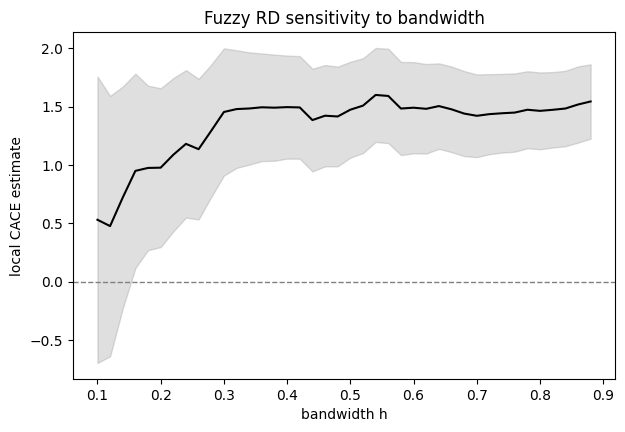

      h  estimate      se    n
0  0.10    0.5306  0.6254  278
1  0.12    0.4765  0.5687  334
2  0.14    0.7206  0.4846  397
3  0.16    0.9491  0.4245  468
4  0.18    0.9742  0.3593  522


In [8]:
def simulate_fuzzy_rd(n=3000, x0=0.0, seed=3):
    rs = np.random.default_rng(seed)
    X = rs.uniform(-1, 1, n)
    Z = (X >= x0).astype(int)
    # probability of receiving treatment jumps at the cutoff but isn't deterministic
    p_treat = 0.15 + 0.5 * Z + 0.1 * (X - x0)
    p_treat = np.clip(p_treat, 0, 1)
    D = rs.binomial(1, p_treat)
    true_effect = 1.5
    Y = 2 + 0.8 * X + true_effect * D + rs.normal(0, 1, n)
    return pd.DataFrame({"X": X, "Z": Z, "D": D, "Y": Y})


def frd_estimate(data, x0, h, x_col="X", z_col="Z", d_col="D", y_col="Y"):
    sub = data[(data[x_col] >= x0 - h) & (data[x_col] <= x0 + h)].copy()
    sub["L"] = np.minimum(sub[x_col] - x0, 0)
    sub["R"] = np.maximum(sub[x_col] - x0, 0)
    beta_D, se_D, fstat = tsls(sub[y_col], sub[d_col], sub[z_col], X=sub[["L", "R"]].values)
    return beta_D, se_D, len(sub)


def frd_sensitivity(data, x0, h_grid, **kwargs):
    rows = [dict(h=h, **dict(zip(["estimate", "se", "n"], frd_estimate(data, x0, h, **kwargs))))
            for h in h_grid]
    return pd.DataFrame(rows)


rd_data = simulate_fuzzy_rd()
sens = frd_sensitivity(rd_data, x0=0.0, h_grid=np.arange(0.1, 0.9, 0.02))

fig, ax = plt.subplots()
ax.plot(sens.h, sens.estimate, color="black")
ax.fill_between(sens.h, sens.estimate - 1.96 * sens.se, sens.estimate + 1.96 * sens.se,
                 alpha=0.25, color="grey")
ax.axhline(0, linestyle="--", color="grey", linewidth=1)
ax.set_xlabel("bandwidth h")
ax.set_ylabel("local CACE estimate")
ax.set_title("Fuzzy RD sensitivity to bandwidth")
plt.show()

print(sens.head())


## 8. Mendelian Randomization from summary statistics (Ch. 25)

When you only have per-instrument coefficients (`gamma_j` = SNP→exposure,
`Gamma_j` = SNP→outcome) and their standard errors — the typical GWAS summary-data
setting — use inverse-variance-weighted (Fisher) combination or Egger regression.


In [9]:
def fisher_weighted_mr(gamma, se_gamma, Gamma, se_Gamma):
    """Simple (suboptimal but common) fixed-effect MR estimator, weighting by 1/se_Gamma^2."""
    gamma, Gamma, se_Gamma = map(np.asarray, (gamma, Gamma, se_Gamma))
    w = gamma ** 2 / se_Gamma ** 2
    beta = np.sum(Gamma * gamma / se_Gamma ** 2) / np.sum(w)
    se = 1 / np.sqrt(np.sum(w))
    return beta, se


def egger_regression(gamma, Gamma, se_Gamma, with_intercept=True):
    """WLS of Gamma_j on gamma_j (optionally with intercept), weights = 1/se_Gamma^2.
    Returns (beta, se_beta, intercept, se_intercept)."""
    gamma, Gamma, se_Gamma = map(np.asarray, (gamma, Gamma, se_Gamma))
    w = 1 / se_Gamma ** 2
    X = sm.add_constant(gamma) if with_intercept else gamma.reshape(-1, 1)
    model = sm.WLS(Gamma, X, weights=w).fit()
    if with_intercept:
        return model.params[1], model.bse[1], model.params[0], model.bse[0]
    return model.params[0], model.bse[0], np.nan, np.nan


def simulate_mr_summary_stats(p=100, true_beta=0.3, pleiotropy_sd=0.0, seed=4):
    """Simulate per-SNP summary stats. pleiotropy_sd > 0 breaks exclusion restriction."""
    rs = np.random.default_rng(seed)
    gamma = rs.normal(0.1, 0.05, p)          # true SNP -> exposure effects
    alpha = rs.normal(0, pleiotropy_sd, p)   # true direct (pleiotropic) SNP -> outcome effects
    se_gamma = np.abs(rs.normal(0.01, 0.002, p))
    se_Gamma = np.abs(rs.normal(0.01, 0.002, p))
    gamma_hat = gamma + rs.normal(0, se_gamma)
    Gamma_true = true_beta * gamma + alpha
    Gamma_hat = Gamma_true + rs.normal(0, se_Gamma)
    return gamma_hat, se_gamma, Gamma_hat, se_Gamma


# No pleiotropy: both estimators should recover true_beta = 0.3
g, se_g, G, se_G = simulate_mr_summary_stats(pleiotropy_sd=0.0)
beta_fw, se_fw = fisher_weighted_mr(g, se_g, G, se_G)
beta_eg, se_eg, icpt, se_icpt = egger_regression(g, G, se_G)
print("No pleiotropy:")
print(f"  Fisher-weighted beta: {beta_fw:.3f} (SE {se_fw:.3f})")
print(f"  Egger beta:           {beta_eg:.3f} (SE {se_eg:.3f}), intercept {icpt:.4f} (SE {se_icpt:.4f})")

# With pleiotropy (InSIDE assumption still holds since alpha is independent of gamma):
g2, se_g2, G2, se_G2 = simulate_mr_summary_stats(pleiotropy_sd=0.05, seed=7)
beta_fw2, se_fw2 = fisher_weighted_mr(g2, se_g2, G2, se_G2)
beta_eg2, se_eg2, icpt2, se_icpt2 = egger_regression(g2, G2, se_G2)
print("\nWith pleiotropy (InSIDE holds):")
print(f"  Fisher-weighted beta: {beta_fw2:.3f} (SE {se_fw2:.3f})  <- can be biased")
print(f"  Egger beta:           {beta_eg2:.3f} (SE {se_eg2:.3f}), intercept {icpt2:.4f} (SE {se_icpt2:.4f})  "
      "<- intercept flags average pleiotropy")


No pleiotropy:
  Fisher-weighted beta: 0.301 (SE 0.008)
  Egger beta:           0.284 (SE 0.016), intercept 0.0022 (SE 0.0019)

With pleiotropy (InSIDE holds):
  Fisher-weighted beta: 0.239 (SE 0.009)  <- can be biased
  Egger beta:           0.225 (SE 0.098), intercept 0.0016 (SE 0.0098)  <- intercept flags average pleiotropy


## 9. Apply this template to your own project

Copy this cell block into a new notebook (or a new section below) and fill it in.
It mirrors the *Applicability Checklist* document — resolve each `# TODO` before
trusting the output.


In [10]:
# ---- 1. Load your data -------------------------------------------------
# df = pd.read_csv("your_data.csv")
# Z, D, Y = df["assigned"], df["received"], df["outcome"]
# X = df[["covariate1", "covariate2"]].values   # optional

# ---- 2. Sanity-check relevance & the monotonicity implication ---------
# tau_D, tau_Y, cace = iv_wald(Z, D, Y)
# assert tau_D > 0, "Weak or reversed first stage -- revisit instrument choice"
# print("pr(D=1|Z=1) - pr(D=1|Z=0):", D[Z==1].mean() - D[Z==0].mean())  # testable monotonicity implication

# ---- 3. Pick an estimator from Sections 2-6 based on your design ------
# cace, se = iv_wald_delta(Z, D, Y)                       # simple encouragement design
# cace, se = iv_lin_bootstrap(Z, D, Y, X)                 # + covariates
# beta_D, se_D, fstat = tsls(Y, D, Z, X)                  # general linear / multiple IVs

# ---- 4. If the instrument could be weak, report a FAR CI too ----------
# grid = np.arange(-2, 6, 0.02)
# pvals = far_confidence_set(Z, D, Y, grid)
# far_ci = grid[pvals >= 0.05]

# ---- 5. Diagnostics -----------------------------------------------------
# For binary D & Y: iv_inequalities(...) on your observed cell counts
# Compare ITT (tau_Y) and IV/CACE estimates for qualitative agreement

# ---- 6. Report -----------------------------------------------------------
# Report CACE with BOTH the Wald-type CI and the FAR CI, and state explicitly
# that the estimate applies to compliers (see Applicability Checklist, Part F).
print("Template ready -- replace the placeholders above with your project's data.")


Template ready -- replace the placeholders above with your project's data.
